# 第 10 章 · CLIP / InfoNCE 代码实验

[章节网页](../ch10.html)

## 运行内容

- 匹配 Digits 图像与文本标签
- 计算 InfoNCE loss
- 绘制相似度矩阵

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# CLIP / InfoNCE：用 digits 原型图像和文本标签构造图文匹配矩阵。
digits = load_digits()
label_ids = [0, 1, 2, 3, 4]
image_names = [f"digit {i}" for i in label_ids]
text_names = [f"text: number {i}" for i in label_ids]

image_proto = []
for label in label_ids:
    image_proto.append(digits.data[digits.target == label].mean(axis=0))
image_emb = normalize(np.array(image_proto))

text_emb = np.zeros((len(label_ids), image_emb.shape[1]))
for row, label in enumerate(label_ids):
    text_emb[row, label * 6:label * 6 + 6] = 1.0
    text_emb[row] += 0.08 * image_emb[row]
text_emb = normalize(text_emb)

temperature = 0.08
logits = image_emb @ text_emb.T / temperature
probs = np.exp(logits - logits.max(axis=1, keepdims=True))
probs = probs / probs.sum(axis=1, keepdims=True)
clip_loss = log_loss(np.arange(len(label_ids)), probs, labels=np.arange(len(label_ids)))

display(pd.DataFrame(np.round(image_emb @ text_emb.T, 3), index=image_names, columns=text_names))
print("InfoNCE loss:", round(float(clip_loss), 4))

,text: number 0,text: number 1,text: number 2,text: number 3,text: number 4
digit 0,0.256,0.215,0.220,0.290,0.232
digit 1,0.225,0.161,0.205,0.343,0.353
digit 2,0.290,0.255,0.199,0.248,0.195
digit 3,0.352,0.222,0.230,0.243,0.244
digit 4,0.178,0.153,0.115,0.289,0.346


InfoNCE loss: 1.9048


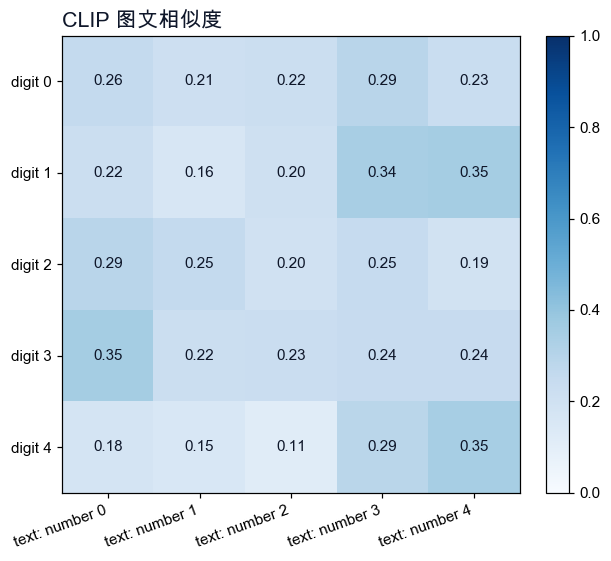

In [3]:
# 绘制图文相似度矩阵。
sim_matrix = image_emb @ text_emb.T
fig, ax = plt.subplots(figsize=(6.6, 5.2))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(text_names)), text_names, rotation=20, ha="right")
ax.set_yticks(range(len(image_names)), image_names)
for i in range(len(image_names)):
    for j in range(len(text_names)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", color="#0f172a")
ax.set_title("CLIP 图文相似度", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()